# VA Analysis LangGraph V02

Clean notebook for the 4-node LangGraph design.

Implemented here:
- Node 01 updates only `issue_category`, `detailed_issue`, and `initial_fix`
- Node 02 updates only `bom_friendly_fix`
- Node 02 uses `dev_test/py/non_ai_flow/github_service.py` via `fetch_analysis_files()`


In [2]:
from pathlib import Path
from pprint import pprint
from typing import Annotated, Literal, Sequence, TypedDict
import os
import sys

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph.state import Command, END, START, StateGraph

load_dotenv()
llm_model = os.getenv("LLM_MODEL")
llm = ChatOpenAI(model=llm_model)


In [3]:
class IssueCore(TypedDict):
    issue_category: Literal["VA", "OTHER"]
    detailed_issue: str
    initial_fix: str


class DetailedIssue(TypedDict):
    issue_category: Literal["VA", "OTHER"]
    detailed_issue: str
    initial_fix: str
    bom_friendly_fix: str


class IssueExtractionResult(TypedDict):
    issue_list: list[IssueCore]


class BomFixOnly(TypedDict):
    bom_friendly_fix: str


class Node02Result(TypedDict):
    issue_list: list[BomFixOnly]


class VaAnalysisState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    issue_list: list[DetailedIssue]


In [4]:
print(Path.cwd())
jenkins_output_raw_text = Path("trivy_scan_input.txt").read_text(encoding="utf-8")
jenkins_output_raw_text[:2000]


d:\DIALOG\DESKTOP\AI -Products\Project 07 - Automated vulnerability detection and remediation for CICD pipelines\PROPER_CODE_BASE\pipeline-security-autofix\dev_test\notebook


"===== build-image.log =====\n\n\n===== scan-dependencies.log =====\n\nReport Summary\n\n┌─────────┬──────┬─────────────────┐\n│ Target  │ Type │ Vulnerabilities │\n├─────────┼──────┼─────────────────┤\n│ pom.xml │ pom  │       30        │\n└─────────┴──────┴─────────────────┘\nLegend:\n- '-': Not scanned\n- '0': Clean (no security findings detected)\n\n\nFor OSS Maintainers: VEX Notice\n--------------------------------\nIf you're an OSS maintainer and Trivy has detected vulnerabilities in your project that you believe are not actually exploitable, consider issuing a VEX (Vulnerability Exploitability eXchange) statement.\nVEX allows you to communicate the actual status of vulnerabilities in your project, improving security transparency and reducing false positives for your users.\nLearn more and start using VEX: https://trivy.dev/docs/v0.70/guide/supply-chain/vex/repo#publishing-vex-documents\n\nTo disable this notice, set the TRIVY_DISABLE_VEX_NOTICE environment variable.\n\n\npom.xml

In [5]:
# NODE 01 -> fetch all issues
# Updates only: issue_category, detailed_issue, initial_fix
# Leaves bom_friendly_fix blank for Node 02
def issue_extraction(state: VaAnalysisState):
    issue_extraction_agent_system_prompt = """
    This agent fetches and analyzes all issues.
    Responsibilities:
    1. Flag each issue as VA or OTHER.
    2. Produce a detailed issue description.
    3. Suggest an initial fix.
    Do not produce bom_friendly_fix here.
    """

    issue_extraction_agent = create_agent(
        model=llm,
        response_format=IssueExtractionResult,
        system_prompt=issue_extraction_agent_system_prompt,
    )

    issue_extraction_agent_response = issue_extraction_agent.invoke({
        "messages": state["messages"]
    })

    pprint(issue_extraction_agent_response)

    core_issues = issue_extraction_agent_response["structured_response"]["issue_list"]
    full_issues: list[DetailedIssue] = [
        {
            "issue_category": issue["issue_category"],
            "detailed_issue": issue["detailed_issue"],
            "initial_fix": issue["initial_fix"],
            "bom_friendly_fix": "",
        }
        for issue in core_issues
    ]

    return Command(update={
        "issue_list": full_issues,
    })


In [6]:
# NODE 02 -> fetch dependency/container files and update only bom_friendly_fix
# Uses dev_test/py/non_ai_flow/github_service.py
def dependency_file_analysis(state: VaAnalysisState, config=None):
    try:
        from non_ai_flow.github_service import fetch_analysis_files
    except ImportError:
        project_root = Path.cwd().resolve().parents[1]
        py_root = project_root / "dev_test" / "py"
        if str(py_root) not in sys.path:
            sys.path.append(str(py_root))
        from non_ai_flow.github_service import fetch_analysis_files

    configurable = (config or {}).get("configurable", {})
    repo_name = configurable.get("repo_name")
    branch_name = configurable.get("branch_name", "main")
    existing_issues = state.get("issue_list", [])

    if not repo_name:
        return Command(update={
            "issue_list": [
                {
                    **issue,
                    "bom_friendly_fix": issue.get("bom_friendly_fix", "") or (
                        "Node 02 skipped because repo_name was not provided in config."
                    ),
                }
                for issue in existing_issues
            ]
        })

    files = fetch_analysis_files(repo_name, branch_name)

    relevant_files = []
    for path, content in files.items():
        lower = path.lower()
        if (
            lower.endswith("pom.xml")
            or lower.endswith("build.gradle")
            or lower.endswith("build.gradle.kts")
            or lower.endswith("dockerfile")
            or lower.endswith("gradle.properties")
            or lower.endswith("settings.gradle")
            or lower.endswith("settings.gradle.kts")
        ):
            relevant_files.append({
                "path": path,
                "content": content,
            })

    issue_lines = []
    for idx, issue in enumerate(existing_issues, start=1):
        issue_lines.append(
            f"Issue {idx}\n"
            f"- issue_category: {issue.get('issue_category', '')}\n"
            f"- detailed_issue: {issue.get('detailed_issue', '')}\n"
            f"- initial_fix: {issue.get('initial_fix', '')}\n"
            f"- current_bom_friendly_fix: {issue.get('bom_friendly_fix', '')}"
        )

    file_lines = []
    for item in relevant_files:
        preview = item["content"][:8000]
        file_lines.append(f"### FILE: {item['path']}\n{preview}")

    node02_prompt = f"""
You are Node 02 in a LangGraph vulnerability remediation workflow.

Task:
Review the extracted issues and the repository dependency/container files.
For each issue, improve ONLY the `bom_friendly_fix` field.

Rules:
1. Do not change issue_category.
2. Do not change detailed_issue.
3. Do not change initial_fix.
4. Update ONLY bom_friendly_fix.
5. Make the fix BOM-friendly and non-conflicting.
6. Prefer a single source of truth:
   - Spring Boot parent/BOM
   - Maven dependencyManagement
   - Gradle platform/version catalog/property
   - Docker base image strategy if relevant
7. Avoid scattered direct overrides when a parent/BOM/platform controls the version.
8. Keep output aligned issue-for-issue with the input order.

Issues:
{chr(10).join(issue_lines) if issue_lines else '- No issues provided.'}

Dependency and container files:
{chr(10).join(file_lines) if file_lines else '- No dependency files found.'}

Return only a structured issue_list where each item contains:
- bom_friendly_fix
"""

    node02_agent = create_agent(
        model=llm,
        response_format=Node02Result,
        system_prompt=(
            "You improve only the bom_friendly_fix field for each issue, using "
            "dependency files to produce BOM-friendly, non-conflicting guidance."
        ),
    )

    node02_response = node02_agent.invoke({
        "messages": [HumanMessage(content=node02_prompt)]
    })

    pprint(node02_response)

    updated_fix_items = node02_response["structured_response"]["issue_list"]

    merged_issue_list = []
    for idx, issue in enumerate(existing_issues):
        new_fix = issue.get("bom_friendly_fix", "")
        if idx < len(updated_fix_items):
            new_fix = updated_fix_items[idx].get("bom_friendly_fix", new_fix)

        merged_issue_list.append({
            **issue,
            "bom_friendly_fix": new_fix,
        })

    return Command(update={
        "issue_list": merged_issue_list,
    })


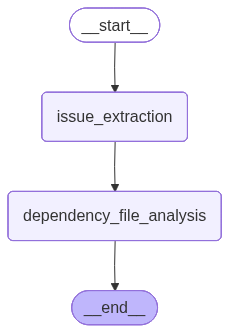

In [7]:
# Graph setup
graph = StateGraph(VaAnalysisState)

graph.add_node(issue_extraction, "issue_extraction")
graph.add_node(dependency_file_analysis, "dependency_file_analysis")

graph.add_edge(START, "issue_extraction")
graph.add_edge("issue_extraction", "dependency_file_analysis")
graph.add_edge("dependency_file_analysis", END)

compiled_graph = graph.compile()
compiled_graph


In [10]:
# Example invoke
# Replace repo_name / branch_name with a real repo before running Node 02
results = compiled_graph.invoke(
    {
        "messages": [HumanMessage(content=jenkins_output_raw_text)],
        "issue_list": [],
    },
    config={
        "configurable": {
            "repo_name": "nishathmnha/demo-springboot-vuln-service",
            "branch_name": "main",
        }
    },
)

pprint(results)


{'messages': [HumanMessage(content='===== build-image.log =====\n\n\n===== scan-dependencies.log =====\n\nReport Summary\n\n┌─────────┬──────┬─────────────────┐\n│ Target  │ Type │ Vulnerabilities │\n├─────────┼──────┼─────────────────┤\n│ pom.xml │ pom  │       30        │\n└─────────┴──────┴─────────────────┘\nLegend:\n- \'-\': Not scanned\n- \'0\': Clean (no security findings detected)\n\n\nFor OSS Maintainers: VEX Notice\n--------------------------------\nIf you\'re an OSS maintainer and Trivy has detected vulnerabilities in your project that you believe are not actually exploitable, consider issuing a VEX (Vulnerability Exploitability eXchange) statement.\nVEX allows you to communicate the actual status of vulnerabilities in your project, improving security transparency and reducing false positives for your users.\nLearn more and start using VEX: https://trivy.dev/docs/v0.70/guide/supply-chain/vex/repo#publishing-vex-documents\n\nTo disable this notice, set the TRIVY_DISABLE_VEX_N